In [1]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import MinMaxScaler

plt.style.use("seaborn-v0_8-whitegrid")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

roll_no = "102317137"
window_size = (sum(int(digit) for digit in roll_no) % 10) + 8
prediction_horizon = (int(roll_no[-2:]) % 3) + 1
hidden_size = (int(roll_no[:3]) % 16) + 8
print(f"Roll no {roll_no} -> window_size={window_size}, prediction_horizon={prediction_horizon}, hidden_size={hidden_size}")

df = pd.read_csv("Electric_Production.csv")
df["DATE"] = pd.to_datetime(df["DATE"], dayfirst=True)
df = df.sort_values("DATE").reset_index(drop=True)
series = df[["Value"]].astype(float).values

train_cut = int(len(series) * 0.70)
val_cut = int(len(series) * 0.85)
scaler = MinMaxScaler()
scaler.fit(series[:train_cut])
scaled_data = scaler.transform(series)
print("Series length:", len(series), "Train/Val/Test target cuts:", train_cut, val_cut)


def create_supervised_sequences(data, window, horizon):
    features, targets, target_indices = [], [], []
    limit = len(data) - horizon + 1
    for end in range(window, limit):
        target_index = end + horizon - 1
        features.append(data[end - window:end])
        targets.append(data[target_index])
        target_indices.append(target_index)
    return np.asarray(features, dtype=np.float32), np.asarray(targets, dtype=np.float32), np.asarray(target_indices, dtype=np.int64)


def split_by_target_index(features, targets, target_indices, train_end, val_end):
    train_mask = target_indices < train_end
    val_mask = (target_indices >= train_end) & (target_indices < val_end)
    test_mask = target_indices >= val_end
    return (
        features[train_mask], targets[train_mask],
        features[val_mask], targets[val_mask],
        features[test_mask], targets[test_mask],
    )


def inverse_transform(values):
    return scaler.inverse_transform(np.asarray(values).reshape(-1, 1)).ravel()


def make_windows(window, horizon):
    features, targets, target_indices = create_supervised_sequences(scaled_data, window, horizon)
    train_x, train_y, val_x, val_y, test_x, test_y = split_by_target_index(features, targets, target_indices, train_cut, val_cut)
    return train_x, train_y, val_x, val_y, test_x, test_y


def build_datasets(train_x, train_y, val_x, val_y, test_x, test_y, batch_size=32):
    train_ds = tf.data.Dataset.from_tensor_slices((train_x, train_y)).shuffle(len(train_x), seed=SEED, reshuffle_each_iteration=True).batch(batch_size)
    val_ds = tf.data.Dataset.from_tensor_slices((val_x, val_y)).batch(batch_size)
    test_ds = tf.data.Dataset.from_tensor_slices((test_x, test_y)).batch(batch_size)
    return train_ds, val_ds, test_ds


def plot_loss(history, title):
    plt.figure(figsize=(8, 4))
    plt.plot(history.history["loss"], label="train")
    plt.plot(history.history["val_loss"], label="val")
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel("MSE loss")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_predictions(actual, predicted, title):
    plt.figure(figsize=(12, 4))
    plt.plot(actual, label="Actual", linewidth=2)
    plt.plot(predicted, label="Predicted", linewidth=1.7)
    plt.title(title)
    plt.xlabel("Test sample index")
    plt.ylabel("Electric production")
    plt.legend()
    plt.tight_layout()
    plt.show()


def build_mlp(window):
    inputs = tf.keras.Input(shape=(window, 1))
    x = tf.keras.layers.Flatten()(inputs)
    x = tf.keras.layers.Dense(hidden_size * 2, activation="relu")(x)
    x = tf.keras.layers.Dense(hidden_size, activation="relu")(x)
    outputs = tf.keras.layers.Dense(1)(x)
    model = tf.keras.Model(inputs, outputs, name="MLP_Baseline")
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss="mse")
    return model


def build_gru(window):
    inputs = tf.keras.Input(shape=(window, 1))
    x = tf.keras.layers.GRU(hidden_size, name="library_gru")(inputs)
    x = tf.keras.layers.Dense(hidden_size, activation="relu")(x)
    outputs = tf.keras.layers.Dense(1)(x)
    model = tf.keras.Model(inputs, outputs, name="Custom_GRU_Library")
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss="mse")
    return model


def build_lstm(window):
    inputs = tf.keras.Input(shape=(window, 1))
    x = tf.keras.layers.LSTM(hidden_size)(inputs)
    x = tf.keras.layers.Dense(hidden_size, activation="relu")(x)
    outputs = tf.keras.layers.Dense(1)(x)
    model = tf.keras.Model(inputs, outputs, name="LSTM")
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss="mse")
    return model


def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout=0.1):
    x = tf.keras.layers.LayerNormalization(epsilon=1e-6)(inputs)
    x = tf.keras.layers.MultiHeadAttention(key_dim=head_size, num_heads=num_heads, dropout=dropout)(x, x)
    x = tf.keras.layers.Dropout(dropout)(x)
    res = tf.keras.layers.Add()([x, inputs])
    x = tf.keras.layers.LayerNormalization(epsilon=1e-6)(res)
    x = tf.keras.layers.Dense(ff_dim, activation="relu")(x)
    x = tf.keras.layers.Dropout(dropout)(x)
    x = tf.keras.layers.Dense(inputs.shape[-1])(x)
    return tf.keras.layers.Add()([x, res])


def build_transformer(window):
    inputs = tf.keras.Input(shape=(window, 1))
    x = tf.keras.layers.Dense(hidden_size)(inputs)
    x = transformer_encoder(x, head_size=max(4, hidden_size // 2), num_heads=2, ff_dim=hidden_size * 2)
    x = transformer_encoder(x, head_size=max(4, hidden_size // 2), num_heads=2, ff_dim=hidden_size * 2)
    x = tf.keras.layers.GlobalAveragePooling1D()(x)
    x = tf.keras.layers.Dense(hidden_size, activation="relu")(x)
    outputs = tf.keras.layers.Dense(1)(x)
    model = tf.keras.Model(inputs, outputs, name="Transformer")
    model.compile(optimizer=tf.keras.optimizers.Adam(8e-4), loss="mse")
    return model


def fit_and_predict(builder, train_x, train_y, val_x, val_y, test_x, test_y, model_name, epochs=80):
    model = builder(train_x.shape[1])
    callback = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)
    history = model.fit(
        train_x,
        train_y,
        validation_data=(val_x, val_y),
        epochs=epochs,
        batch_size=32,
        verbose=0,
        shuffle=False,
        callbacks=[callback],
    )
    predicted_scaled = model.predict(test_x, verbose=0).ravel()
    actual = inverse_transform(test_y.ravel())
    predicted = inverse_transform(predicted_scaled)
    mse = mean_squared_error(actual, predicted)
    mae = mean_absolute_error(actual, predicted)
    rmse = mse ** 0.5
    print(f"{model_name}: MSE={mse:.4f}, MAE={mae:.4f}, RMSE={rmse:.4f}")
    return model, history, actual, predicted, {"Model": model_name, "MSE": mse, "MAE": mae, "RMSE": rmse}


Roll no 102317137 -> window_size=13, prediction_horizon=2, hidden_size=14
Series length: 397 Train/Val/Test target cuts: 277 337


Original window shapes: (263, 13, 1) (60, 13, 1) (60, 13, 1)
MLP Baseline: MSE=21.6032, MAE=3.0510, RMSE=4.6479


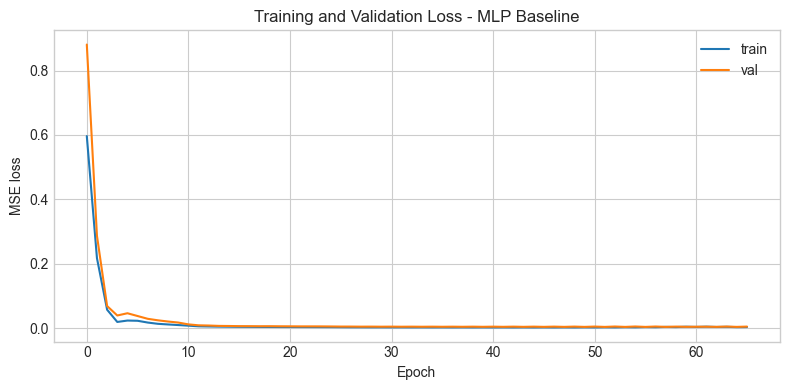

Custom GRU: MSE=50.7559, MAE=5.3128, RMSE=7.1243


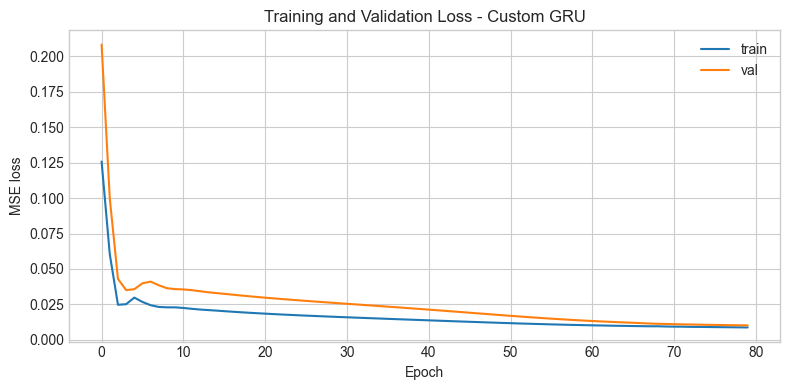

LSTM: MSE=60.1422, MAE=6.2828, RMSE=7.7551


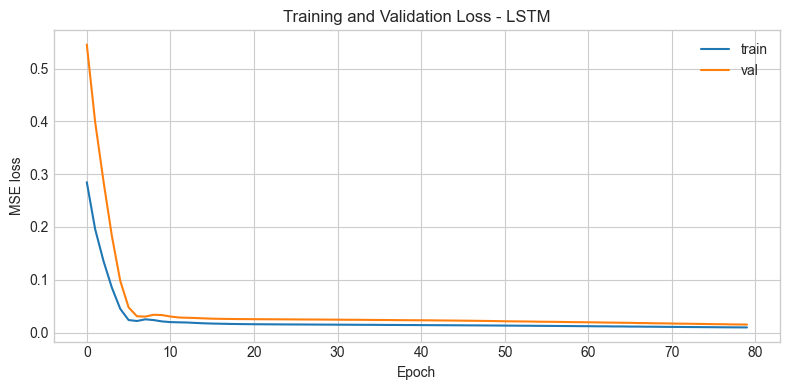

Transformer: MSE=105.2814, MAE=8.3770, RMSE=10.2607


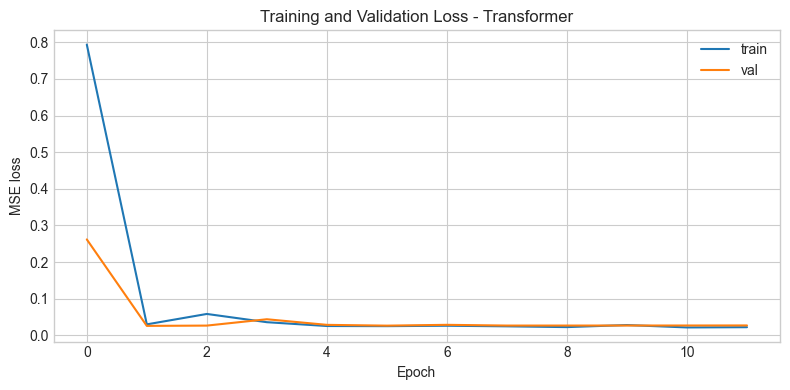


Original-window comparison:
       Model        MSE      MAE      RMSE
MLP Baseline  21.603207 3.051020  4.647925
  Custom GRU  50.755886 5.312794  7.124317
        LSTM  60.142178 6.282815  7.755139
 Transformer 105.281380 8.376951 10.260672


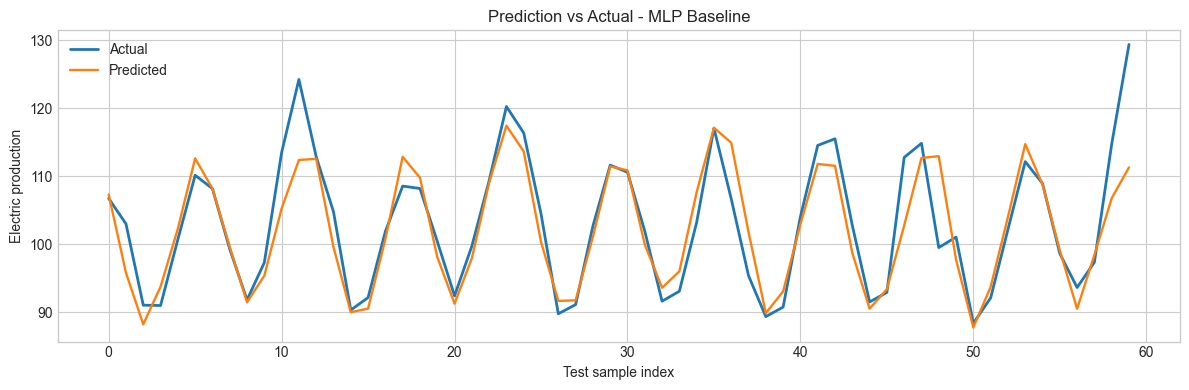

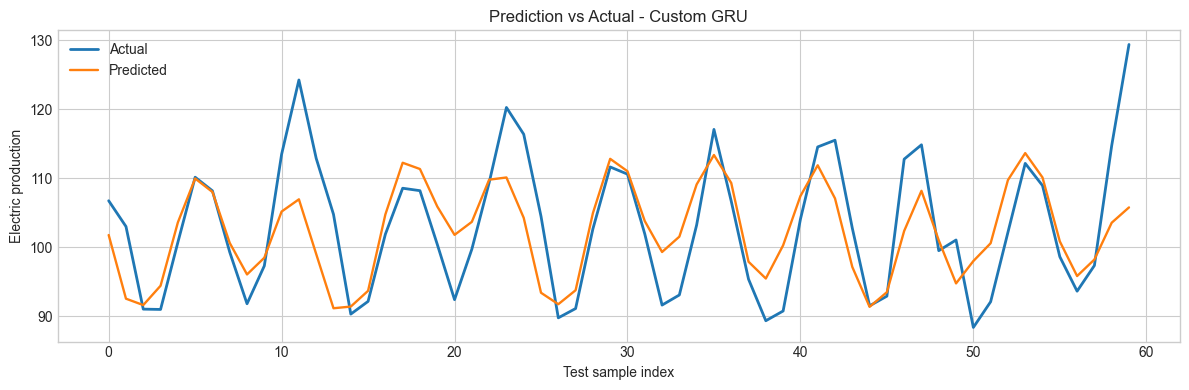

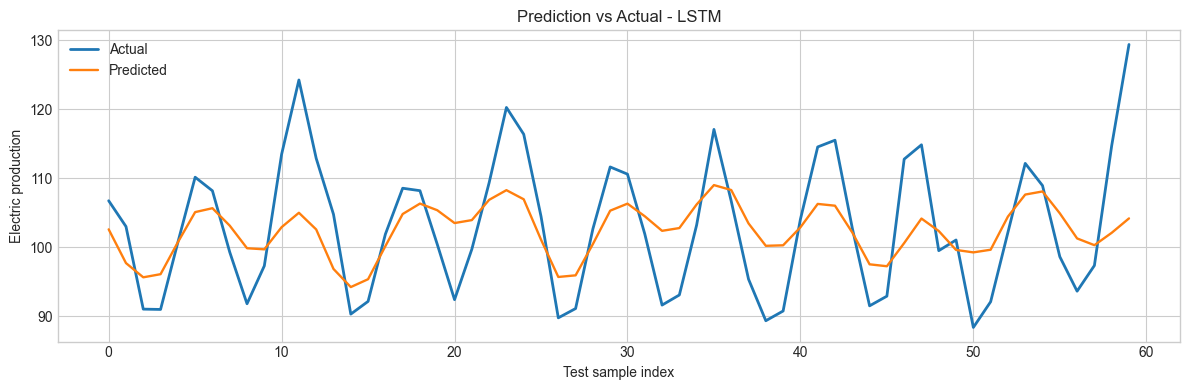

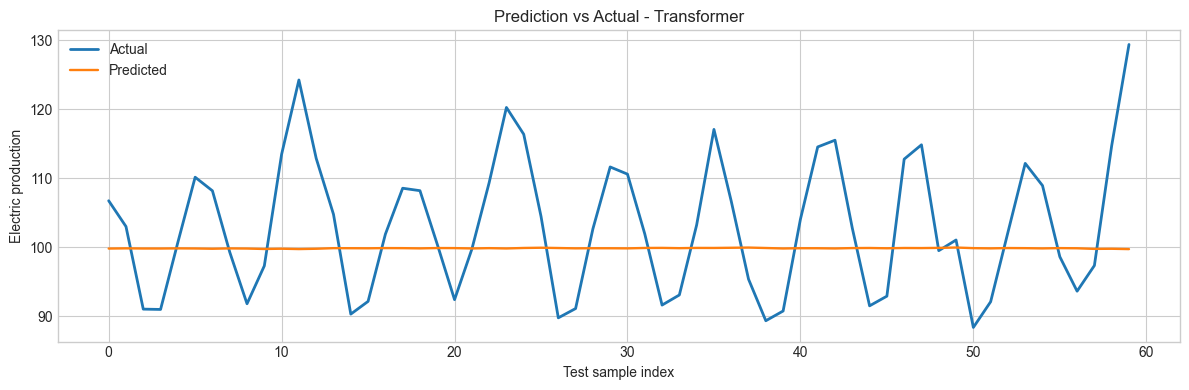

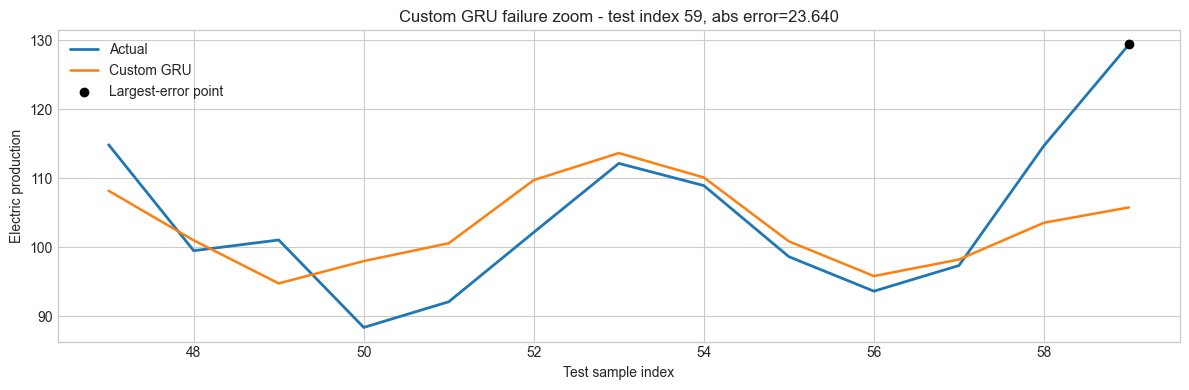

Largest custom-GRU error occurs near test index 59: actual=129.405, predicted=105.765, abs_error=23.640


In [3]:
train_x, train_y, val_x, val_y, test_x, test_y = make_windows(window_size, prediction_horizon)
print("Original window shapes:", train_x.shape, val_x.shape, test_x.shape)

models = {
    "MLP Baseline": build_mlp,
    "Custom GRU": build_gru,
    "LSTM": build_lstm,
    "Transformer": build_transformer,
}

trained = {}
metrics_rows = []
actual_reference = None
predictions_reference = {}
history_reference = {}

for name, builder in models.items():
    model, history, actual, predicted, metrics = fit_and_predict(builder, train_x, train_y, val_x, val_y, test_x, test_y, name)
    trained[name] = model
    history_reference[name] = history
    predictions_reference[name] = predicted
    actual_reference = actual
    metrics_rows.append(metrics)
    plot_loss(history, f"Training and Validation Loss - {name}")

results = pd.DataFrame(metrics_rows).sort_values("RMSE").reset_index(drop=True)
print("\nOriginal-window comparison:")
print(results.to_string(index=False))

for name, predicted in predictions_reference.items():
    plot_predictions(actual_reference, predicted, f"Prediction vs Actual - {name}")

custom_abs_error = np.abs(actual_reference - predictions_reference["Custom GRU"])
worst_index = int(np.argmax(custom_abs_error))
zoom_start = max(0, worst_index - 12)
zoom_end = min(len(actual_reference), worst_index + 13)
plt.figure(figsize=(12, 4))
plt.plot(range(zoom_start, zoom_end), actual_reference[zoom_start:zoom_end], label="Actual", linewidth=2)
plt.plot(range(zoom_start, zoom_end), predictions_reference["Custom GRU"][zoom_start:zoom_end], label="Custom GRU", linewidth=1.8)
plt.scatter([worst_index], [actual_reference[worst_index]], color="black", zorder=5, label="Largest-error point")
plt.title(f"Custom GRU failure zoom - test index {worst_index}, abs error={custom_abs_error[worst_index]:.3f}")
plt.xlabel("Test sample index")
plt.ylabel("Electric production")
plt.legend()
plt.tight_layout()
plt.show()

print(
    f"Largest custom-GRU error occurs near test index {worst_index}: "
    f"actual={actual_reference[worst_index]:.3f}, predicted={predictions_reference['Custom GRU'][worst_index]:.3f}, "
    f"abs_error={custom_abs_error[worst_index]:.3f}"
)


Custom GRU - Half window: MSE=75.0056, MAE=6.9204, RMSE=8.6606


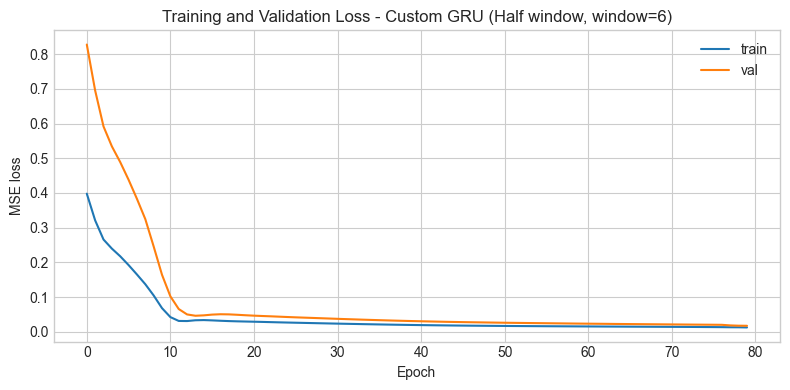

Custom GRU - Original window: MSE=90.0043, MAE=7.8824, RMSE=9.4871


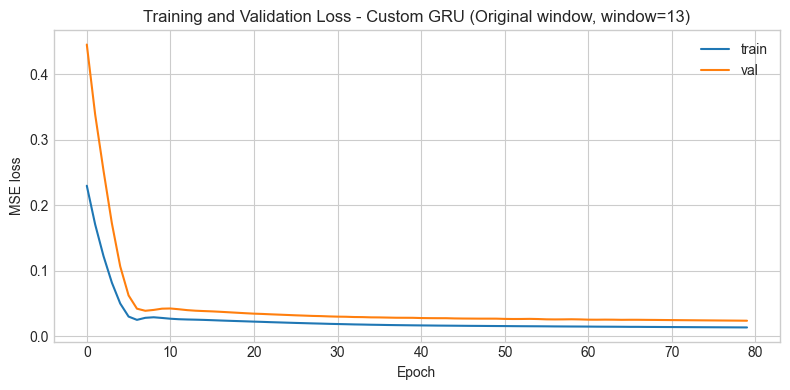

Custom GRU - Double window: MSE=82.7502, MAE=7.3933, RMSE=9.0967


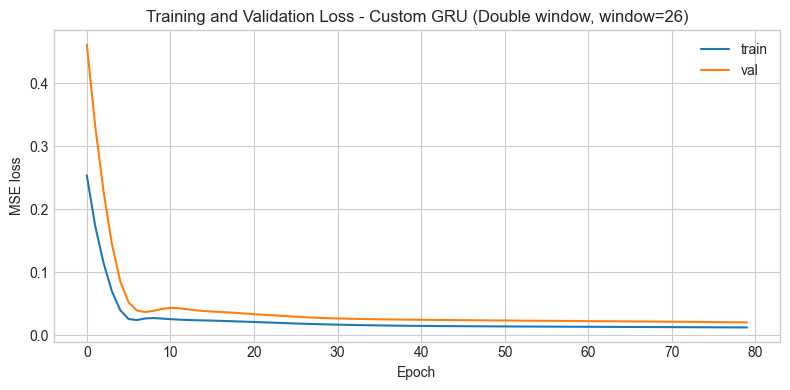


Custom GRU ablation results:
 Window setting  Window size       MSE      MAE     RMSE  Delta RMSE vs original
    Half window            6 75.005615 6.920425 8.660578                1.536262
Original window           13 90.004257 7.882370 9.487057                2.362741
  Double window           26 82.750214 7.393275 9.096714                1.972398


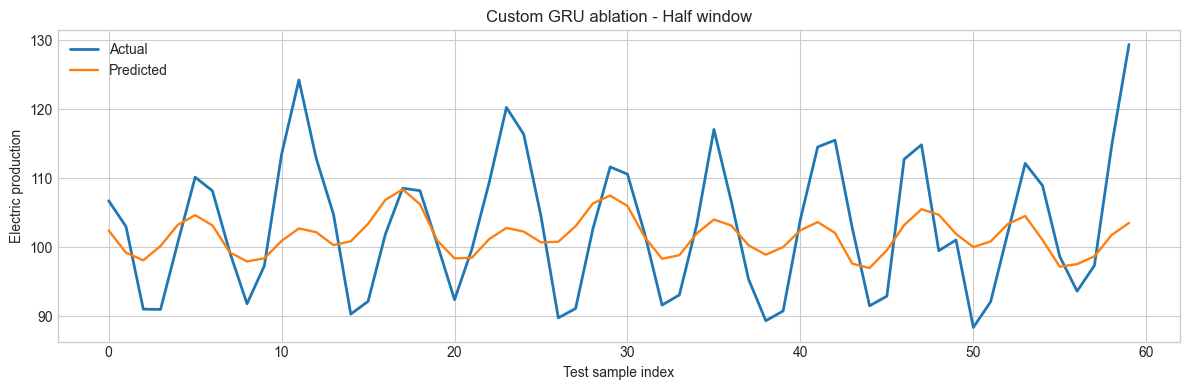

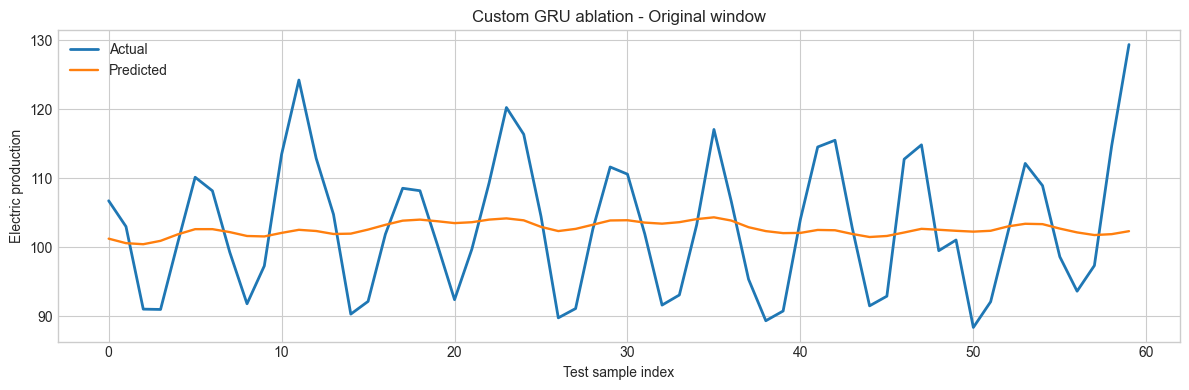

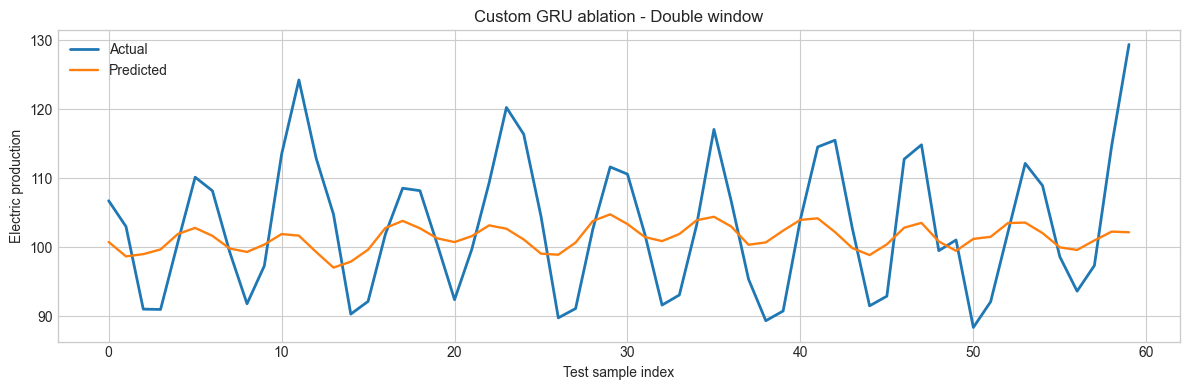

Worst ablation setting: Original window (window=13), RMSE=9.4871, which is +2.3627 vs the original window.


In [4]:
ablation_windows = {
    "Half window": max(2, window_size // 2),
    "Original window": window_size,
    "Double window": window_size * 2,
}

ablation_rows = []
ablation_histories = {}
ablation_predictions = {}
ablation_actual = None
original_custom_rmse = float(results.loc[results["Model"] == "Custom GRU", "RMSE"].iloc[0])

for label, ablation_window in ablation_windows.items():
    ax_train_x, ax_train_y, ax_val_x, ax_val_y, ax_test_x, ax_test_y = make_windows(ablation_window, prediction_horizon)
    model, history, actual, predicted, metrics = fit_and_predict(build_gru, ax_train_x, ax_train_y, ax_val_x, ax_val_y, ax_test_x, ax_test_y, f"Custom GRU - {label}")
    ablation_histories[label] = history
    ablation_predictions[label] = predicted
    ablation_actual = actual
    metrics["Window setting"] = label
    metrics["Window size"] = ablation_window
    metrics["Delta RMSE vs original"] = metrics["RMSE"] - original_custom_rmse
    ablation_rows.append(metrics)
    plot_loss(history, f"Training and Validation Loss - Custom GRU ({label}, window={ablation_window})")

ablation_results = pd.DataFrame(ablation_rows).sort_values("Window size").reset_index(drop=True)
print("\nCustom GRU ablation results:")
print(ablation_results[["Window setting", "Window size", "MSE", "MAE", "RMSE", "Delta RMSE vs original"]].to_string(index=False))

for label, predicted in ablation_predictions.items():
    plot_predictions(ablation_actual, predicted, f"Custom GRU ablation - {label}")

worst_setting = ablation_results.sort_values("RMSE", ascending=False).iloc[0]
print(
    f"Worst ablation setting: {worst_setting['Window setting']} (window={int(worst_setting['Window size'])}), "
    f"RMSE={worst_setting['RMSE']:.4f}, which is {worst_setting['Delta RMSE vs original']:+.4f} vs the original window."
)
